In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTModel, GPT2Model, GPT2LMHeadModel, GPT2Config
from transformers import ViTConfig
import torchvision.transforms as transforms
from PIL import Image
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import os
from collections import Counter
import spacy
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load spaCy model for tokenization
try:
    spacy_eng = spacy.load("en_core_web_sm")
except:
    os.system("python -m spacy download en_core_web_sm")
    spacy_eng = spacy.load("en_core_web_sm")

Using device: cuda


In [2]:
# ==================== VOCABULARY ====================
class Vocabulary:
    def __init__(self, freq_threshold=4):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return [token.text.lower() for token in spacy_eng.tokenizer(str(text))]

    def build_vocab(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenize(text)
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenized_text]

# ==================== DATASET ====================
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=4):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform

        self.imgs = self.df["image_name"]
        self.captions = self.df["comment"]

        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocab(self.captions.tolist())

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = self.captions[idx]
        img_name = self.imgs[idx]
        img_location = os.path.join(self.root_dir, img_name)
        img = Image.open(img_location).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        caption_vec = [self.vocab.stoi["<SOS>"]] + self.vocab.numericalize(caption) + [self.vocab.stoi["<EOS>"]]

        return img, torch.tensor(caption_vec)


In [3]:
# ==================== VIT ENCODER ====================
class ViTEncoder(nn.Module):
    def __init__(self, model_name='google/vit-base-patch16-224', embedding_dim=512):
        super(ViTEncoder, self).__init__()
        # Load pre-trained ViT model
        self.vit = ViTModel.from_pretrained(model_name)
        
        # Projector to match decoder's embedding dimension if needed
        self.projection = nn.Linear(768, embedding_dim) if embedding_dim != 768 else nn.Identity()
        
        # Freeze ViT parameters (optional - can be unfrozen for fine-tuning)
        for param in self.vit.parameters():
            param.requires_grad = False

    def forward(self, images):
        # Get ViT features
        outputs = self.vit(pixel_values=images)
        # Use the last hidden state (sequence of patch embeddings)
        features = outputs.last_hidden_state  # (batch_size, seq_len, 768)
        features = self.projection(features)
        return features

# ==================== GPT DECODER ====================
class GPTDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim=512, num_layers=6, num_heads=8, max_seq_len=100):
        super(GPTDecoder, self).__init__()
        
        # Configure GPT-2
        config = GPT2Config(
            vocab_size=vocab_size,
            n_embd=embedding_dim,
            n_layer=num_layers,
            n_head=num_heads,
            n_positions=max_seq_len,
            n_ctx=max_seq_len,
            bos_token_id=1,  # <SOS>
            eos_token_id=2,  # <EOS>
            pad_token_id=0   # <PAD>
        )
        
        self.gpt = GPT2LMHeadModel(config)
        self.embedding_dim = embedding_dim
        
        # Cross-attention layer to incorporate image features
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            batch_first=True
        )
        
        # Project image features to embedding dimension
        # self.image_projection = nn.Linear(512, embedding_dim)

    def forward(self, image_features, captions, attention_mask=None):
        """
        image_features: (batch_size, seq_len, 768) from ViT
        captions: (batch_size, seq_len) - tokenized captions
        """
        batch_size = captions.size(0)
        
        # Project image features
        # image_features = self.image_projection(image_features)
        
        # Get token embeddings
        inputs_embeds = self.gpt.transformer.wte(captions)
        
        # Apply cross-attention between caption tokens and image features
        # Reshape for attention: (batch_size, seq_len, embed_dim)
        attn_output, _ = self.cross_attention(
            query=inputs_embeds,
            key=image_features,
            value=image_features
        )
        
        # Combine original embeddings with attended features
        combined_embeds = inputs_embeds + attn_output
        
        # Forward through GPT
        outputs = self.gpt(
            inputs_embeds=combined_embeds,
            attention_mask=attention_mask,
            labels=captions
        )
        
        return outputs.logits, outputs.loss
    
    def generate(self, image_features, vocab, max_len=80, temperature=1.0):
        """
        Generate caption from image features
        """
        batch_size = image_features.size(0)
        
        # Project image features
        # image_features = self.image_projection(image_features)
        
        # Start with SOS token
        sos_token = torch.full((batch_size, 1), vocab.stoi['<SOS>'], dtype=torch.long).to(image_features.device)
        
        generated = sos_token
        
        for _ in range(max_len):
            # Get embeddings for generated tokens
            inputs_embeds = self.gpt.transformer.wte(generated)
            
            # Cross-attention with image features
            attn_output, _ = self.cross_attention(
                query=inputs_embeds,
                key=image_features,
                value=image_features
            )
            
            # Combine
            combined_embeds = inputs_embeds + attn_output
            
            # Forward through GPT
            outputs = self.gpt(inputs_embeds=combined_embeds)
            logits = outputs.logits
            
            # Get next token predictions
            next_token_logits = logits[:, -1, :] / temperature
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            
            # Append to generated sequence
            generated = torch.cat([generated, next_token], dim=1)
            
            # Stop if all sequences have generated EOS
            if (next_token == vocab.stoi['<EOS>']).all():
                break
        
        return generated

# ==================== COMPLETE MODEL ====================
class ViTGPTImageCaptioning(nn.Module):
    def __init__(self, vocab_size, embedding_dim=512, num_layers=6, num_heads=8, max_seq_len=100):
        super(ViTGPTImageCaptioning, self).__init__()
        
        self.encoder = ViTEncoder(embedding_dim=embedding_dim)
        self.decoder = GPTDecoder(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            num_layers=num_layers,
            num_heads=num_heads,
            max_seq_len=max_seq_len
        )
        
    def forward(self, images, captions, attention_mask=None):
        image_features = self.encoder(images)
        logits, loss = self.decoder(image_features, captions, attention_mask)
        return logits, loss
    
    def generate_caption(self, image, vocab, max_len=80, temperature=1.0):
        """
        Generate caption for a single image
        """
        self.eval()
        with torch.no_grad():
            if image.dim() == 3:
                image = image.unsqueeze(0)
            image_features = self.encoder(image)
            generated_tokens = self.decoder.generate(image_features, vocab, max_len, temperature)
            
            # Convert tokens to words
            caption_words = []
            for token in generated_tokens[0]:
                word = vocab.itos[token.item()]
                if word == '<EOS>':
                    break
                if word not in ['<PAD>', '<SOS>']:
                    caption_words.append(word)
            
            return ' '.join(caption_words)



In [4]:
# ==================== DATA TRANSFORMS ====================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==================== COLLATE FUNCTION ====================
def collate_fn(batch):
    batch = [(img, cap) for img, cap in batch if cap is not None and len(cap) > 0]
    
    if len(batch) == 0:
        return None, None
    
    batch.sort(key=lambda x: len(x[1]), reverse=True)
    images, captions = zip(*batch)
    
    # Pad captions
    padded_captions = pad_sequence(captions, batch_first=True, padding_value=0)
    
    # Stack images
    images = torch.stack(images, 0)
    
    return images, padded_captions


In [5]:
# ==================== DATA LOADING ====================
data_location = "/kaggle/input/datasets/eeshawn/flickr30k"

# Load dataset
full_dataset = FlickrDataset(
    root_dir=data_location + "/flickr30k_images/",
    captions_file=data_location + "/captions.txt",
    transform=train_transform
)

# Split dataset
from torch.utils.data import random_split

generator = torch.Generator().manual_seed(42)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# Update transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Create dataloaders
batch_size = 128  # Adjust based on GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
print(f"Vocabulary size: {len(full_dataset.vocab)}")

Train samples: 111240, Validation samples: 23837, Test samples: 23838
Vocabulary size: 8523


In [6]:
# ==================== INITIALIZE MODEL ====================
vocab_size = len(full_dataset.vocab)
embedding_dim = 512
num_layers = 12
num_heads = 8
max_seq_len = 100

model = ViTGPTImageCaptioning(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_layers=num_layers,
    num_heads=num_heads,
    max_seq_len=max_seq_len
).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Vocabulary size: {vocab_size}")

# ==================== OPTIMIZER AND LOSS ====================
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model initialized with 130,078,208 parameters
Vocabulary size: 8523


In [7]:
# ==================== TRAINING FUNCTIONS ====================
def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch_idx, (imgs, caps) in enumerate(progress_bar):
        if imgs is None or caps is None:
            continue
        
        imgs = imgs.to(device)
        caps = caps.to(device)
        
        if caps.size(1) < 2:
            continue
        
        # Prepare decoder input (remove last token) and targets (remove first token)
        decoder_input = caps[:, :-1]
        targets = caps[:, 1:]
        
        # Create attention mask (ignore padding)
        attention_mask = (decoder_input != 0).long()
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        logits, loss = model(imgs, decoder_input, attention_mask)
        
        if loss is None:
            continue
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(dataloader)

def validate_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    valid_batches = 0
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Validation')
        for imgs, caps in progress_bar:
            if imgs is None or caps is None:
                continue
            
            imgs = imgs.to(device)
            caps = caps.to(device)
            
            if caps.size(1) < 2:
                continue
            
            decoder_input = caps[:, :-1]
            targets = caps[:, 1:]
            attention_mask = (decoder_input != 0).long()
            
            logits, loss = model(imgs, decoder_input, attention_mask)
            
            if loss is None:
                continue
            
            total_loss += loss.item()
            valid_batches += 1
            progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / valid_batches if valid_batches > 0 else 0


In [8]:
# ==================== METRICS FUNCTIONS ====================
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

def calculate_bleu_scores(references, hypotheses):
    smoothie = SmoothingFunction().method4
    refs = [[ref.split()] for ref in references]
    hyps = [hyp.split() for hyp in hypotheses]
    
    bleu1 = corpus_bleu(refs, hyps, weights=(1.0, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = corpus_bleu(refs, hyps, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu3 = corpus_bleu(refs, hyps, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    
    return bleu1, bleu2, bleu3, bleu4

def evaluate_metrics(model, dataloader, vocab, device, num_samples=200):
    model.eval()
    references = []
    hypotheses = []
    
    with torch.no_grad():
        for i, (imgs, caps) in enumerate(tqdm(dataloader, desc='Evaluating metrics')):
            if len(references) >= num_samples:
                break
            
            imgs = imgs.to(device)
            
            for j in range(min(imgs.size(0), num_samples - len(references))):
                # Generate caption
                caption = model.generate_caption(imgs[j], vocab, max_len=50)
                hypotheses.append(caption)
                
                # Get ground truth
                gt_caption = caps[j].cpu().numpy()
                gt_words = []
                for idx in gt_caption:
                    word = vocab.itos[idx]
                    if word == '<EOS>':
                        break
                    if word not in ['<PAD>', '<SOS>']:
                        gt_words.append(word)
                references.append(' '.join(gt_words))
    
    bleu1, bleu2, bleu3, bleu4 = calculate_bleu_scores(references, hypotheses)
    
    print(f"\nCalculated metrics on {len(references)} samples:")
    print(f"  BLEU-1: {bleu1:.4f}")
    print(f"  BLEU-2: {bleu2:.4f}")
    print(f"  BLEU-3: {bleu3:.4f}")
    print(f"  BLEU-4: {bleu4:.4f}")
    
    return {
        'BLEU-1': bleu1,
        'BLEU-2': bleu2,
        'BLEU-3': bleu3,
        'BLEU-4': bleu4,
    }


In [12]:
def load_model(model_path, device='cuda'):
    # 1. Load the state dictionary
    state_dict = torch.load(model_path, weights_only=False)
    # 2. Load the state dictionary into the model
    model.load_state_dict(state_dict)
    return model


model = load_model("/kaggle/input/notebooks/salmanrajravuri/vit-gpt/best_vit_gpt_model.pth")

In [29]:
# ==================== TEST ON SAMPLE IMAGES ====================
test_image_paths = [
    data_location + "/flickr30k_images/1003163366.jpg",
    data_location + "/flickr30k_images/1005216151.jpg",
    data_location + "/flickr30k_images/1009434119.jpg"
]

print("\n" + "="*50)
print("TESTING ON SAMPLE IMAGES")
print("="*50)

for img_path in test_image_paths:
    if os.path.exists(img_path):
        # Load and preprocess image
        image = Image.open(img_path).convert('RGB')
        image_tensor = val_transform(image).to(device)
        
        # Generate caption
        caption = model.generate_caption(image_tensor, full_dataset.vocab)
        print(f"\nImage: {os.path.basename(img_path)}")
        print(f"Generated Caption: {caption}")


TESTING ON SAMPLE IMAGES

Image: 1003163366.jpg
Generated Caption: a man is sleeping on a bench with his dog .

Image: 1005216151.jpg
Generated Caption: a crowd of people are walking down the street .

Image: 1009434119.jpg
Generated Caption: a black and white dog is running through the grass .


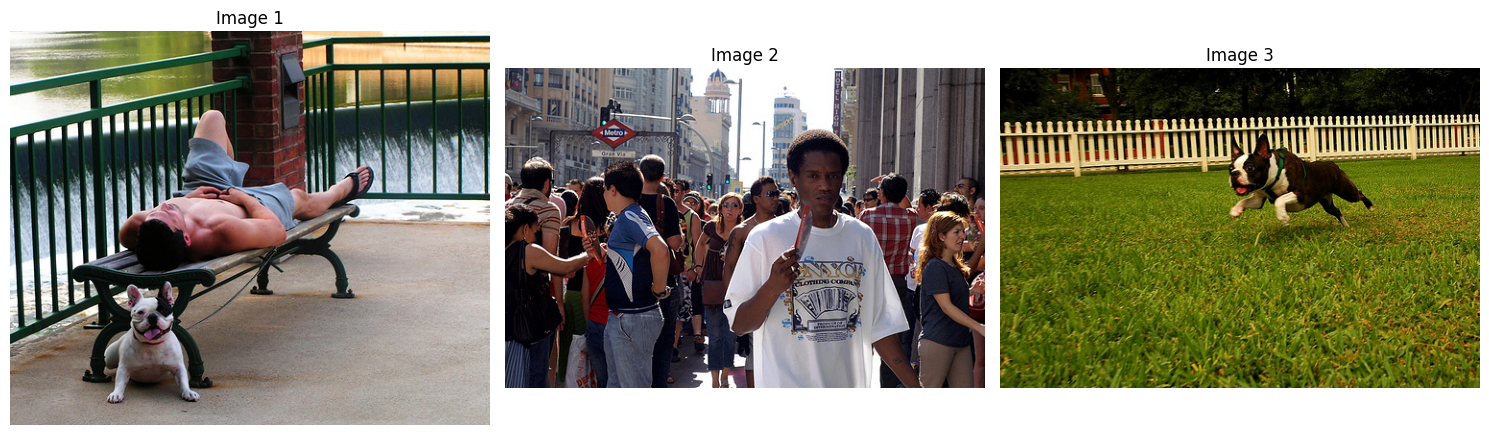

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_images(image_paths):
    """Display multiple images from given paths"""
    num_images = len(image_paths)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, num_images, figsize=(5*num_images, 5))
    
    # If only one image, make axes iterable
    if num_images == 1:
        axes = [axes]
    
    for idx, img_path in enumerate(image_paths):
        try:
            # Load and display image
            img = mpimg.imread(img_path)
            axes[idx].imshow(img)
            axes[idx].axis('off')  # Turn off axis
            axes[idx].set_title(f'Image {idx+1}', fontsize=12)
        except FileNotFoundError:
            axes[idx].text(0.5, 0.5, f'File not found:\n{img_path}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error loading image:\n{str(e)}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display images
display_images(test_image_paths)

In [32]:
# ==================== BLEU SCORES FOR SAMPLE IMAGES ====================
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import os

# Reference captions (ground truth) - Flickr30k dataset నుండి
# ఈ images కి actual captions CSV లో ఉంటాయి
def get_reference_captions(img_name, df):
    """DataFrame నుండి ఒక image కి అన్ని reference captions తీసుకుంటుంది"""
    refs = df[df['image_name'] == img_name]['comment'].tolist()
    return refs

smoothie = SmoothingFunction().method4

test_image_paths = [
    data_location + "/flickr30k_images/1003163366.jpg",
    data_location + "/flickr30k_images/1005216151.jpg",
    data_location + "",
]

print("=" * 60)
print("BLEU SCORES FOR SAMPLE IMAGES")
print("=" * 60)

all_bleu1, all_bleu2, all_bleu3, all_bleu4 = [], [], [], []

model.eval()
for img_path in test_image_paths:
    if not os.path.exists(img_path):
        print(f"⚠ Not found: {img_path}")
        continue

    img_name = os.path.basename(img_path)

    # Caption generate
    image = Image.open(img_path).convert('RGB')
    image_tensor = val_transform(image).to(device)
    with torch.no_grad():
        generated = model.generate_caption(image_tensor, full_dataset.vocab)

    # Reference captions
    refs = get_reference_captions(img_name, full_dataset.df)
    if not refs:
        print(f"⚠ No references found for: {img_name}")
        continue

    # Tokenize
    hypothesis = generated.split()
    references = [r.split() for r in refs]

    # BLEU scores
    b1 = sentence_bleu(references, hypothesis, weights=(1,0,0,0),             smoothing_function=smoothie)
    b2 = sentence_bleu(references, hypothesis, weights=(0.5,0.5,0,0),         smoothing_function=smoothie)
    b3 = sentence_bleu(references, hypothesis, weights=(0.33,0.33,0.33,0),    smoothing_function=smoothie)
    b4 = sentence_bleu(references, hypothesis, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

    all_bleu1.append(b1)
    all_bleu2.append(b2)
    all_bleu3.append(b3)
    all_bleu4.append(b4)

    print(f"\nImage   : {img_name}")
    print(f"Generated : {generated}")
    print(f"References:")
    for i, r in enumerate(refs, 1):
        print(f"  [{i}] {r}")
    print(f"BLEU-1  : {b1:.4f}")
    print(f"BLEU-2  : {b2:.4f}")
    print(f"BLEU-3  : {b3:.4f}")
    print(f"BLEU-4  : {b4:.4f}")
    print("-" * 60)

# ==================== AVERAGE BLEU ====================
if all_bleu1:
    print("\n" + "=" * 60)
    print("AVERAGE BLEU SCORES")
    print("=" * 60)
    print(f"  Avg BLEU-1 : {sum(all_bleu1)/len(all_bleu1):.4f}")
    print(f"  Avg BLEU-2 : {sum(all_bleu2)/len(all_bleu2):.4f}")
    print(f"  Avg BLEU-3 : {sum(all_bleu3)/len(all_bleu3):.4f}")
    print(f"  Avg BLEU-4 : {sum(all_bleu4)/len(all_bleu4):.4f}")
    print("=" * 60)

BLEU SCORES FOR SAMPLE IMAGES

Image   : 1003163366.jpg
Generated : a man is sleeping on a bench with his dog .
References:
  [1] a man sleeping on a bench outside with a white and black dog sitting next to him .
  [2] A man lays on the bench to which a white dog is also tied .
  [3] man laying on bench holding leash of dog sitting on ground
  [4] A shirtless man lies on a park bench with his dog .
  [5] A man lays on a bench while his dog sits by him .
BLEU-1  : 1.0000
BLEU-2  : 0.8944
BLEU-3  : 0.7652
BLEU-4  : 0.6389
------------------------------------------------------------

Image   : 1005216151.jpg
Generated : a crowd of people are walking down the street .
References:
  [1] A man in a white t-shirt looks toward the camera surrounded by a crowd near a metro station .
  [2] A large crowd of people stand outside in front of the entrance to a Metro station .
  [3] A group of people are walking through a city street .
  [4] A crowd is portrayed near a metro station .
  [5] Crowd sta

In [36]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import os, random
from PIL import Image
import torch
from tqdm import tqdm

def get_reference_captions(img_name, df):
    return df[df['image_name'] == img_name]['comment'].tolist()

smoothie = SmoothingFunction().method4

image_folder = data_location + "/flickr30k_images"
all_images = os.listdir(image_folder)

# 🔥 RANDOM SPLIT (200–400)
sample_size = 500   # 👉 change between 200–400
sampled_images = random.sample(all_images, sample_size)

print("=" * 60)
print(f"TOTAL SELECTED IMAGES: {len(sampled_images)}")
print("=" * 60)

all_bleu1, all_bleu2, all_bleu3, all_bleu4 = [], [], [], []

model.eval()

for img_name in tqdm(sampled_images):

    img_path = os.path.join(image_folder, img_name)

    try:
        image = Image.open(img_path).convert('RGB')
    except:
        continue

    image_tensor = val_transform(image).to(device)

    with torch.no_grad():
        generated = model.generate_caption(image_tensor, full_dataset.vocab)

    refs = get_reference_captions(img_name, full_dataset.df)

    if not refs:
        continue

    hypothesis = generated.split()
    references = [r.split() for r in refs]

    b1 = sentence_bleu(references, hypothesis, weights=(1,0,0,0), smoothing_function=smoothie)
    b2 = sentence_bleu(references, hypothesis, weights=(0.5,0.5,0,0), smoothing_function=smoothie)
    b3 = sentence_bleu(references, hypothesis, weights=(0.33,0.33,0.33,0), smoothing_function=smoothie)
    b4 = sentence_bleu(references, hypothesis, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

    all_bleu1.append(b1)
    all_bleu2.append(b2)
    all_bleu3.append(b3)
    all_bleu4.append(b4)

# ==================== FINAL AVG ====================
print("\n" + "=" * 60)
print("AVERAGE BLEU SCORES (500 IMAGES)")
print("=" * 60)

print(f"Avg BLEU-1 : {sum(all_bleu1)/len(all_bleu1):.4f}")
print(f"Avg BLEU-2 : {sum(all_bleu2)/len(all_bleu2):.4f}")
print(f"Avg BLEU-3 : {sum(all_bleu3)/len(all_bleu3):.4f}")
print(f"Avg BLEU-4 : {sum(all_bleu4)/len(all_bleu4):.4f}")

print("=" * 60)

TOTAL SELECTED IMAGES: 500


100%|██████████| 500/500 [01:28<00:00,  5.66it/s]


AVERAGE BLEU SCORES (1000 IMAGES)
Avg BLEU-1 : 0.6872
Avg BLEU-2 : 0.4866
Avg BLEU-3 : 0.3522
Avg BLEU-4 : 0.2541



  LRP  |  IMAGE: 1003163366.jpg
  Original : a man sleeping on a bench outside with a white and black dog sitting next to him .
  Predicted: a man is sleeping on a bench with his dog .

Computing LRP patch relevance...
  Patch relevance range: [0.0000, 0.0495]

Top-5 LRP regions (by mean relevance):
  R1  mean_relevance=0.2857  area=5890px (11.7%)
  R2  mean_relevance=0.1188  area=2902px (5.8%)
  R3  mean_relevance=0.0852  area=652px (1.3%)
  R4  mean_relevance=0.0774  area=632px (1.3%)
  R5  mean_relevance=0.0713  area=2226px (4.4%)


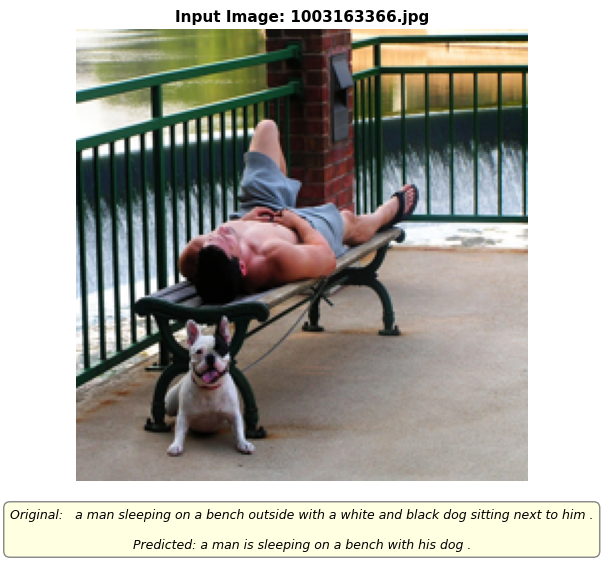


Saved: 1003163366_lrp_fig1_captions.png


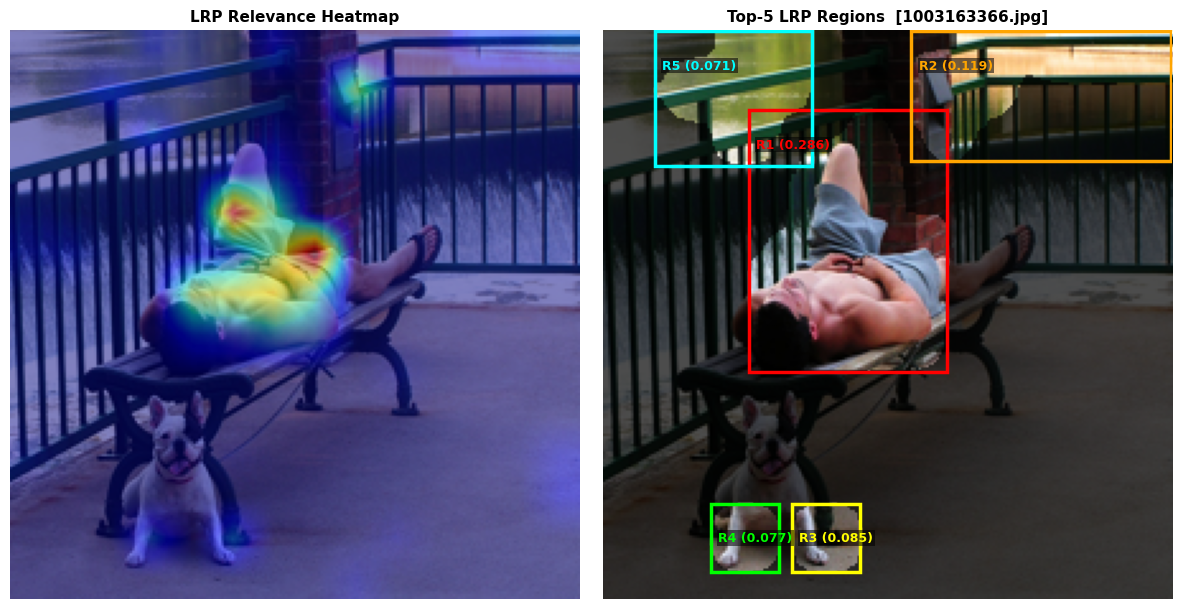

Saved: 1003163366_lrp_fig2_regions.png


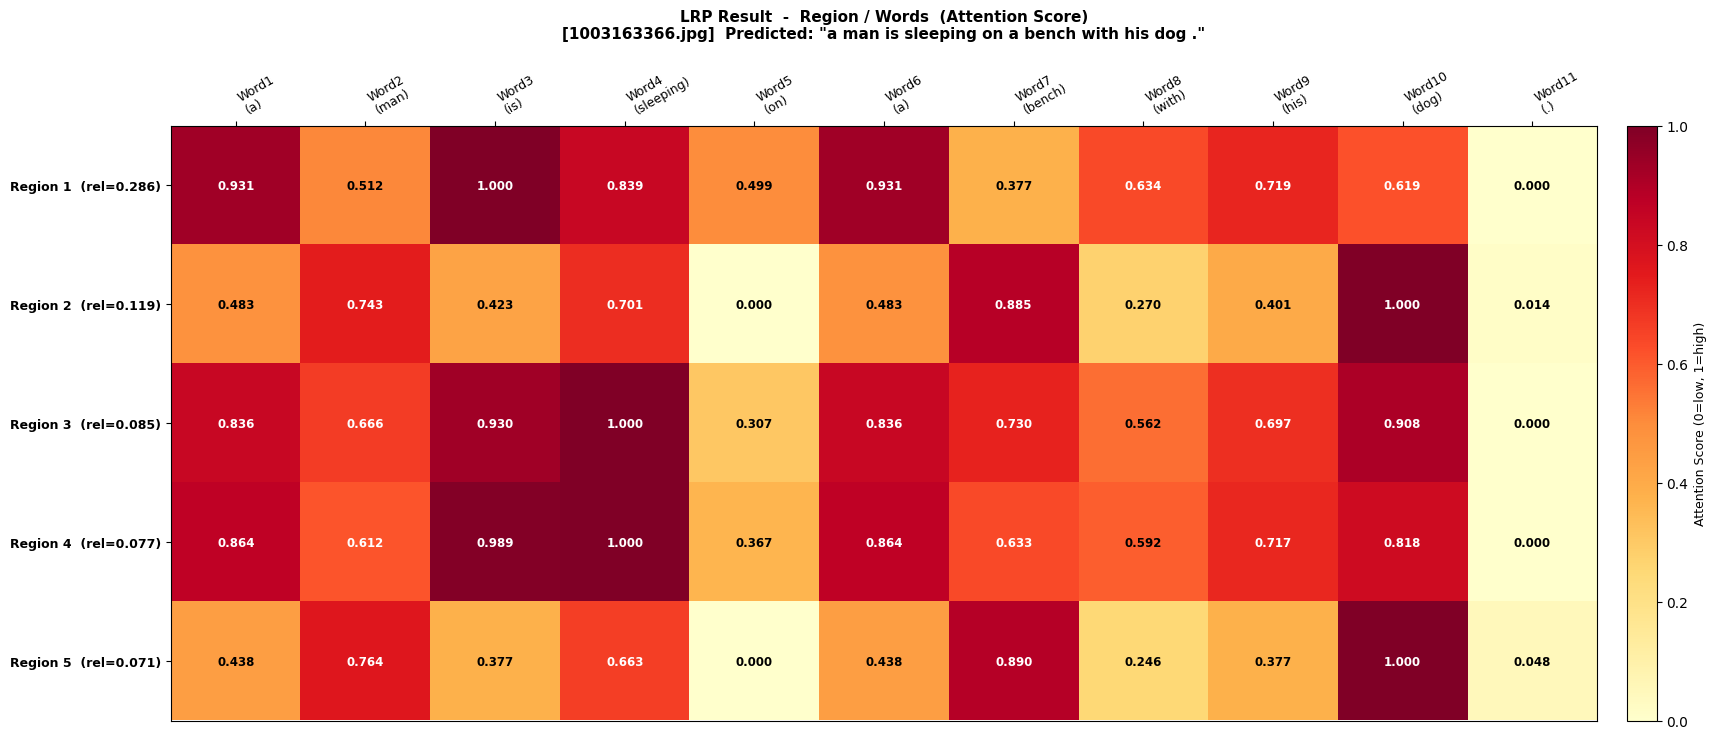

Saved: 1003163366_lrp_fig3_heatmap.png

----------------------------------------------------------------------------------------------------------------------------------------------------
Region/Words           Word1       Word2       Word3       Word4       Word5       Word6       Word7       Word8       Word9      Word10      Word11
                         (a)       (man)        (is)  (sleeping)        (on)         (a)     (bench)      (with)       (his)       (dog)         (.)
----------------------------------------------------------------------------------------------------------------------------------------------------
Region 1              0.9314      0.5116      1.0000      0.8395      0.4989      0.9314      0.3769      0.6343      0.7191      0.6188      0.0000
Region 2              0.4834      0.7431      0.4229      0.7008      0.0000      0.4834      0.8853      0.2699      0.4007      1.0000      0.0142
Region 3              0.8362      0.6662      0.9302      1.0000  

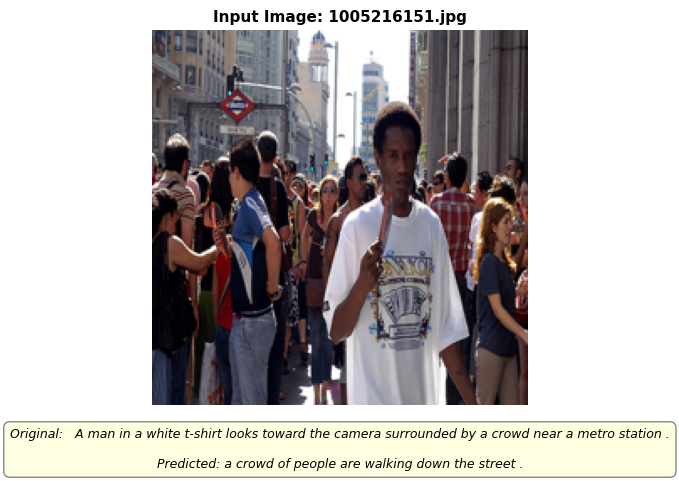


Saved: 1005216151_lrp_fig1_captions.png


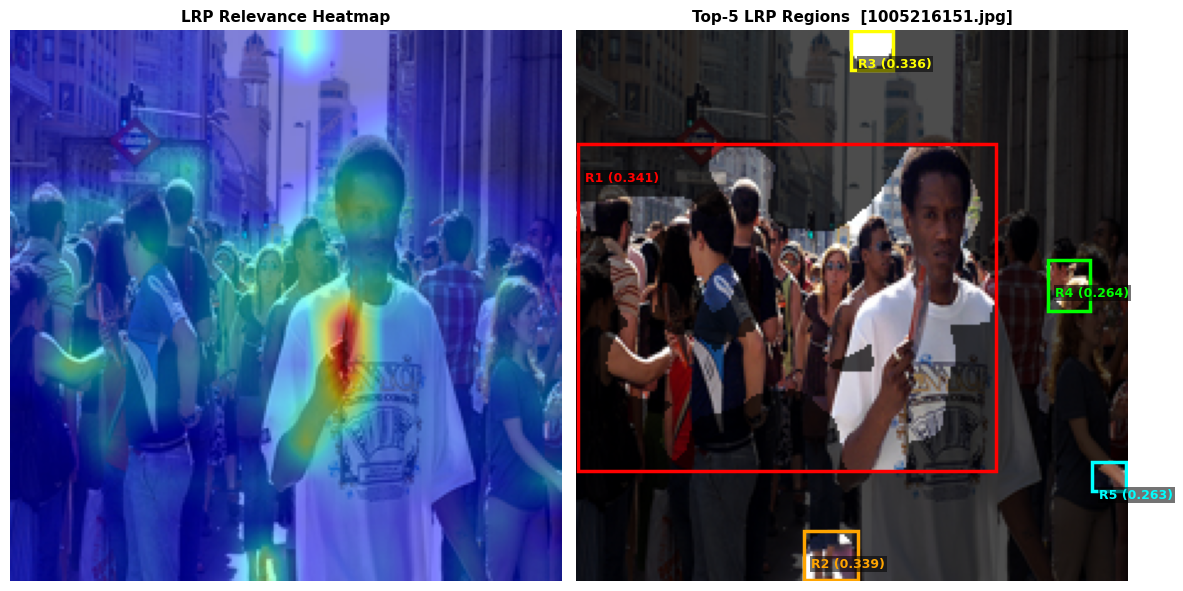

Saved: 1005216151_lrp_fig2_regions.png


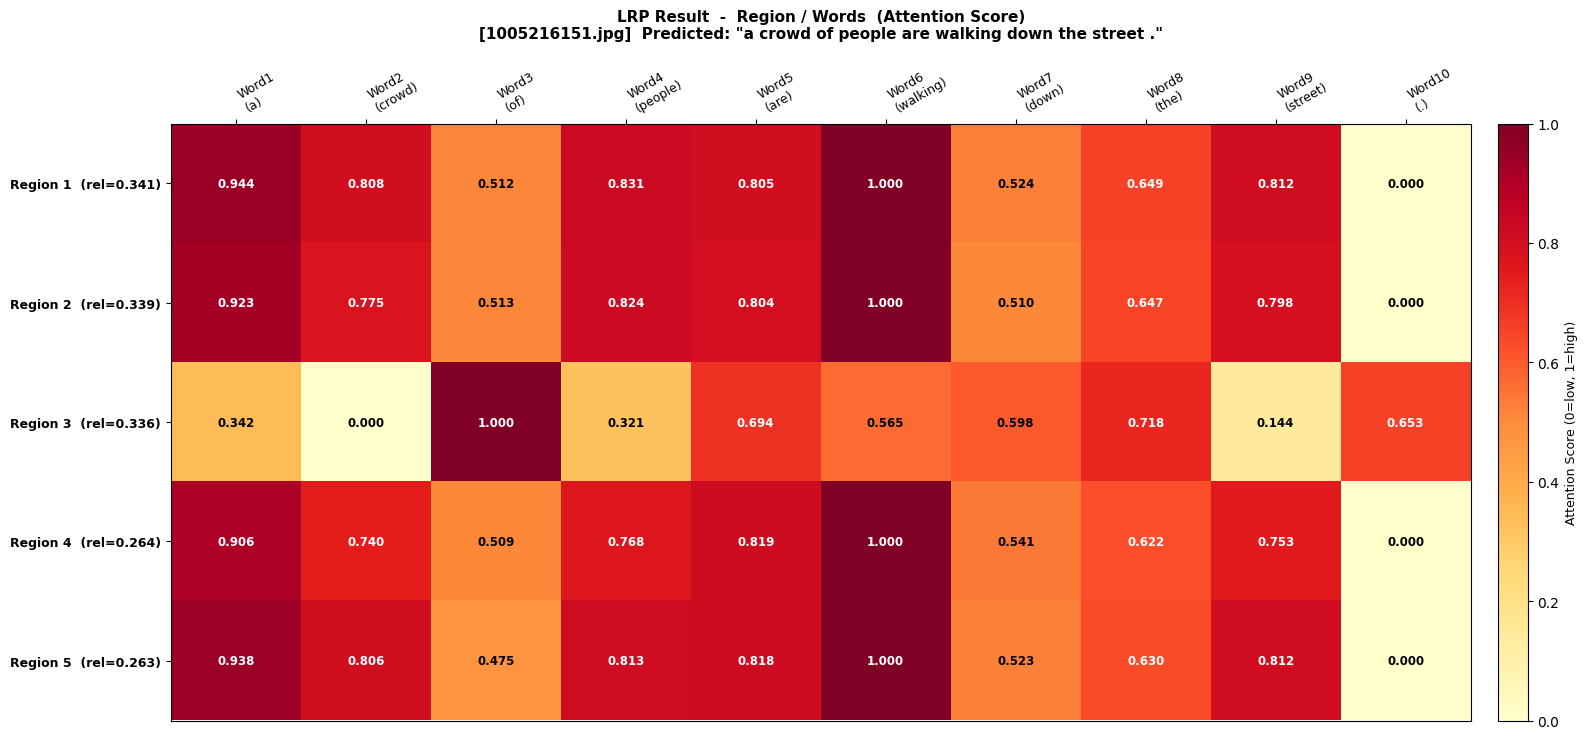

Saved: 1005216151_lrp_fig3_heatmap.png

------------------------------------------------------------------------------------------------------------------------------
Region/Words          Word1      Word2      Word3      Word4      Word5      Word6      Word7      Word8      Word9     Word10
                        (a)    (crowd)       (of)   (people)      (are)  (walking)     (down)      (the)   (street)        (.)
------------------------------------------------------------------------------------------------------------------------------
Region 1             0.9436     0.8085     0.5119     0.8309     0.8052     1.0000     0.5245     0.6488     0.8120     0.0000
Region 2             0.9229     0.7749     0.5133     0.8240     0.8042     1.0000     0.5096     0.6466     0.7979     0.0000
Region 3             0.3425     0.0000     1.0000     0.3208     0.6944     0.5650     0.5983     0.7185     0.1439     0.6528
Region 4             0.9062     0.7405     0.5086     0.7678     0.8186

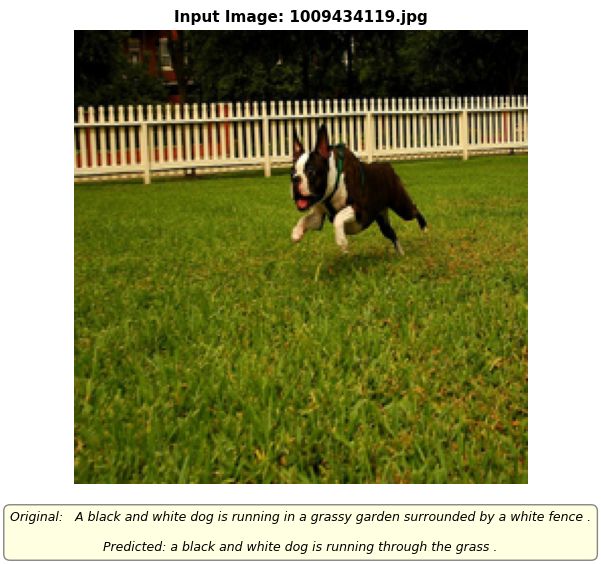


Saved: 1009434119_lrp_fig1_captions.png


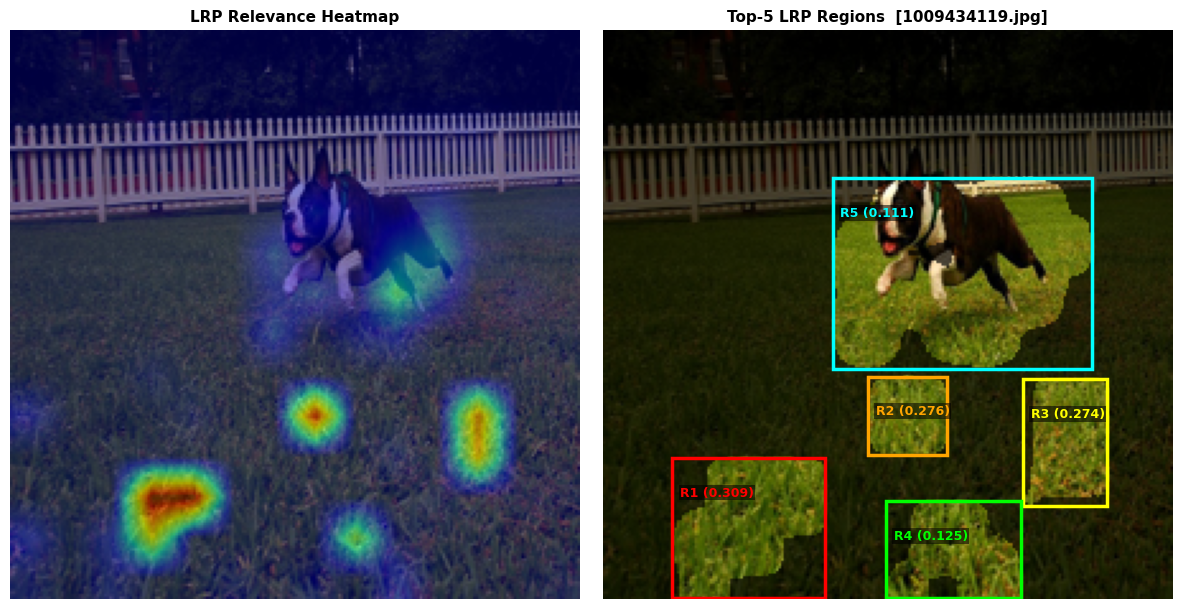

Saved: 1009434119_lrp_fig2_regions.png


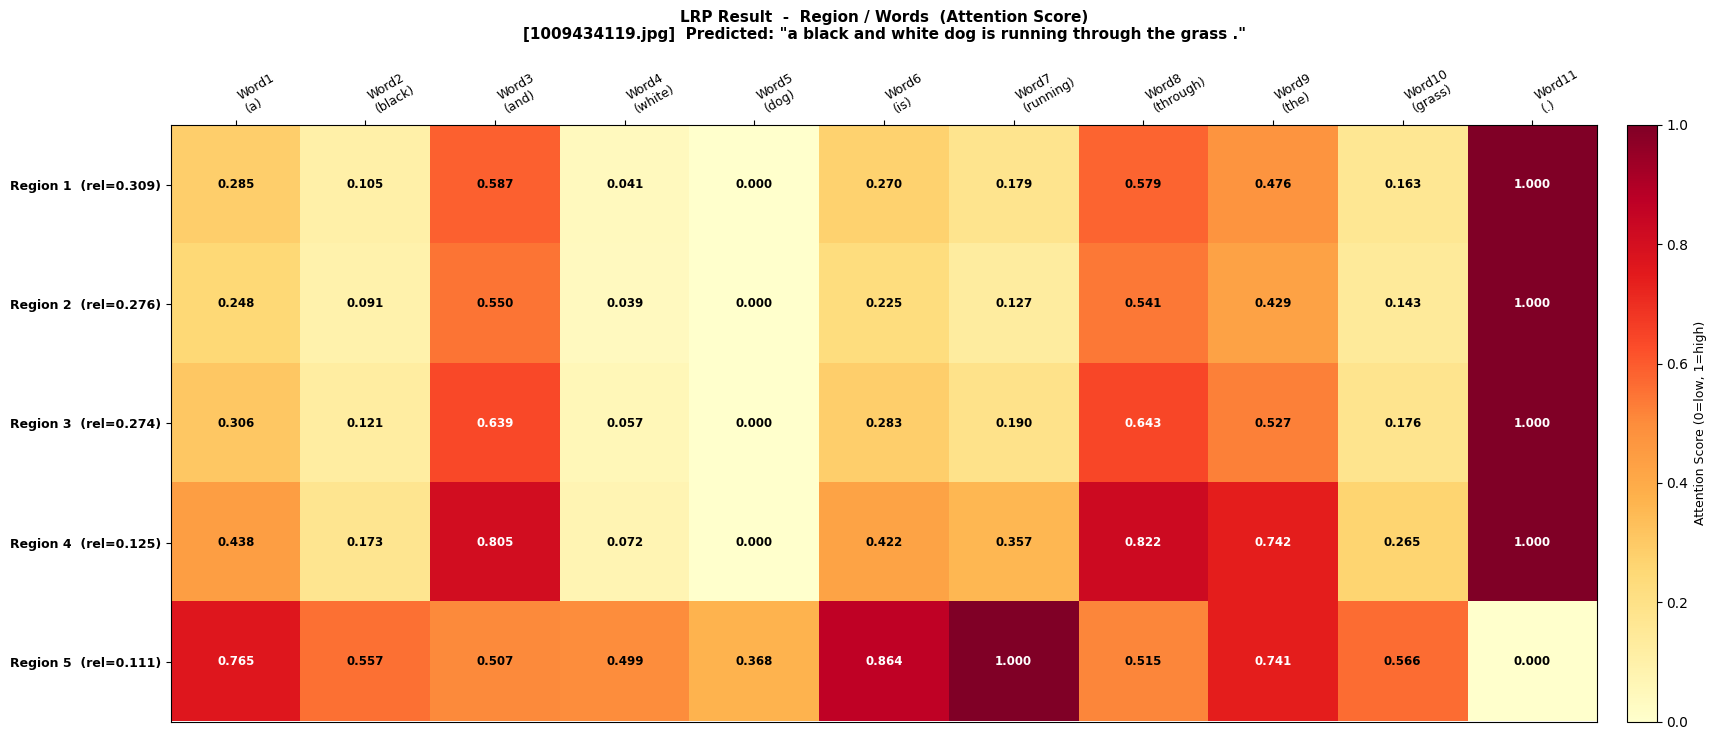

Saved: 1009434119_lrp_fig3_heatmap.png

-----------------------------------------------------------------------------------------------------------------------------------------
Region/Words          Word1      Word2      Word3      Word4      Word5      Word6      Word7      Word8      Word9     Word10     Word11
                        (a)    (black)      (and)    (white)      (dog)       (is)  (running)  (through)      (the)    (grass)        (.)
-----------------------------------------------------------------------------------------------------------------------------------------
Region 1             0.2850     0.1051     0.5868     0.0408     0.0000     0.2701     0.1787     0.5794     0.4762     0.1635     1.0000
Region 2             0.2478     0.0908     0.5500     0.0389     0.0000     0.2254     0.1271     0.5414     0.4288     0.1429     1.0000
Region 3             0.3057     0.1213     0.6394     0.0566     0.0000     0.2827     0.1904     0.6430     0.5273     0.1761     1

In [38]:
# ==============================================================
# LRP EXPLAINABILITY  -  ViT + GPT Image Captioning
# ==============================================================
# Layer-wise Relevance Propagation (LRP) for ViT encoder.
#
# HOW LRP WORKS HERE:
#   1. Forward pass through ViT encoder -> image_features
#   2. Forward pass through GPTDecoder  -> logits
#   3. Relevance initialised at output (caption log-prob score)
#   4. Backprop relevance through GPTDecoder cross-attention
#      -> relevance per image patch token  (196,)
#   5. Reshape patch relevance -> 14x14 heatmap -> resize to 224x224
#   6. Threshold heatmap -> top-5 connected regions (same as LIME output)
#
# OUTPUT (same 3 figures as LIME):
#   [1] Image + Original Caption + Predicted Caption
#   [2] Image with Top-5 LRP regions highlighted (R1..R5 boxes)
#   [3] Heatmap table:
#          Region/Words | Word1 | Word2 | Word3 | ...
#          Region 1     | 0.82  | 0.34  | 0.17  | ...
#          ...
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn.functional as F
from scipy import ndimage
import os
import warnings
warnings.filterwarnings('ignore')


# ---------------------------------------------------------------
# PART 1 : LRP CORE  -  relevance through cross-attention
# ---------------------------------------------------------------
# We use the Gradient x Input (GradxInput) variant of LRP,
# which is efficient and works well with transformers:
#
#   relevance[patch_i] = sum_over_words(
#       grad(score w.r.t. attn_weight[word, patch_i])
#       * attn_weight[word, patch_i]
#   )
#
# This gives a (196,) relevance score per ViT patch.
# Positive values = patches that support the predicted caption.
# ---------------------------------------------------------------

def compute_lrp_patch_relevance(image_tensor, caption_words):
    """
    Compute LRP-style patch relevance scores.

    Args:
        image_tensor  : (3, 224, 224) tensor on device
        caption_words : list of predicted caption word strings

    Returns:
        patch_relevance : np.ndarray  shape (196,)  non-negative
        attn_matrix     : np.ndarray  shape (196, num_words)
                          (same cross-attention matrix as LIME version)
    """
    model.eval()
    vocab = full_dataset.vocab

    if len(caption_words) == 0:
        return np.zeros(196), np.zeros((196, 1))

    img_input = image_tensor.unsqueeze(0).to(device)  # (1,3,224,224)

    # ── Forward: ViT encoder ─────────────────────────────────────
    image_features = model.encoder(img_input)          # (1, 197, 512)
    # Keep grad on image_features for LRP backprop
    image_features = image_features.detach().requires_grad_(True)

    # ── Forward: token embeddings ────────────────────────────────
    token_ids = [
        vocab.stoi.get(w, vocab.stoi['<UNK>'])
        for w in caption_words
    ]
    token_ids_with_eos = token_ids + [vocab.stoi['<EOS>']]

    full_ids      = [vocab.stoi['<SOS>']] + token_ids_with_eos
    cap_tensor    = torch.tensor([full_ids], dtype=torch.long).to(device)
    decoder_input = cap_tensor[:, :-1]                 # (1, seq_len)
    target_ids    = cap_tensor[:, 1:]                  # (1, seq_len)
    attn_mask     = (decoder_input != vocab.stoi['<PAD>']).long()

    word_embeds = model.decoder.gpt.transformer.wte(
        decoder_input
    )                                                  # (1, seq_len, 512)

    # ── Forward: cross-attention (keep weights) ───────────────────
    attn_output, attn_weights = model.decoder.cross_attention(
        query=word_embeds,
        key=image_features,
        value=image_features,
        need_weights=True,
        average_attn_weights=True   # (1, seq_len, 197) averaged over heads
    )
    # attn_weights: (1, seq_len, 197)

    # combined embeddings -> GPT forward
    combined_embeds = word_embeds + attn_output
    gpt_out = model.decoder.gpt(
        inputs_embeds=combined_embeds,
        attention_mask=attn_mask,
        labels=target_ids
    )
    loss = gpt_out.loss                                # scalar (mean NLL)

    # ── LRP: backprop loss through attn_weights ───────────────────
    # We want relevance of each image patch for the caption score.
    # Score = -loss (higher = better caption generation).
    # Gradient of score w.r.t. attn_weights gives sensitivity per
    # (word, patch) pair.  LRP = grad * attn_weights (GradxInput).

    # attn_weights needs grad
    attn_weights_detached = attn_weights.detach().requires_grad_(True)

    # Recompute attn_output using the grad-tracked attn_weights
    # attn_weights_detached: (1, seq_len, 197)
    # image_features: (1, 197, 512)
    attn_output_recomp = torch.bmm(
        attn_weights_detached,
        image_features
    )                                                  # (1, seq_len, 512)

    combined_recomp = word_embeds.detach() + attn_output_recomp

    gpt_out2 = model.decoder.gpt(
        inputs_embeds=combined_recomp,
        attention_mask=attn_mask,
        labels=target_ids
    )
    score = -gpt_out2.loss                             # higher is better

    score.backward()

    # grad: (1, seq_len, 197)
    grad = attn_weights_detached.grad.detach()         # (1, seq_len, 197)
    aw   = attn_weights_detached.detach()              # (1, seq_len, 197)

    # LRP = grad * attn_weight  (element-wise)
    lrp_raw = (grad * aw)                              # (1, seq_len, 197)

    # Drop CLS token (index 0) -> (1, seq_len, 196)
    lrp_raw = lrp_raw[:, :, 1:]

    # Sum over words -> (196,)  patch-level relevance
    patch_relevance = lrp_raw.squeeze(0).sum(dim=0).cpu().numpy()

    # Keep only positive relevance (LRP convention)
    patch_relevance = np.maximum(patch_relevance, 0)

    # ── Also return per-word attention matrix (for heatmap table) ──
    # aw shape: (1, seq_len, 197) -> drop CLS -> (seq_len, 196) -> T
    aw_np = aw.squeeze(0).cpu().numpy()[:, 1:].T      # (196, seq_len)

    # seq_len here = len(decoder_input) = len(SOS+caption_words)
    # We only want the caption_words columns (skip SOS column 0)
    num_words = len(caption_words)
    attn_matrix = aw_np[:, 1:num_words+1]             # (196, num_words)

    return patch_relevance, attn_matrix


# ---------------------------------------------------------------
# PART 2 : PATCH RELEVANCE -> REGION BOXES
# ---------------------------------------------------------------
# Reshape (196,) -> (14,14) heatmap -> resize to (224,224)
# Threshold at percentile -> binary mask
# Find connected components -> top-N by mean relevance
# ---------------------------------------------------------------

def relevance_to_regions(patch_relevance, top_regions=5,
                          threshold_percentile=70):
    """
    Convert 196-dim patch relevance to top-N bounding-box regions.

    Args:
        patch_relevance      : np.ndarray (196,) non-negative
        top_regions          : number of regions to return
        threshold_percentile : pixels below this percentile zeroed out

    Returns:
        top_region_masks : list of (224,224) bool arrays, length=top_regions
        heatmap_224      : (224,224) float relevance map (for visualisation)
        top_region_scores: list of float mean-relevance per region
    """
    # Reshape to 14x14
    heatmap_14 = patch_relevance.reshape(GRID_SIZE, GRID_SIZE)

    # Resize to 224x224 using bilinear (PIL)
    heatmap_pil = Image.fromarray(
        (heatmap_14 / (heatmap_14.max() + 1e-8) * 255).astype(np.uint8)
    ).resize((224, 224), Image.BILINEAR)
    heatmap_224 = np.array(heatmap_pil).astype(float)
    heatmap_224 /= (heatmap_224.max() + 1e-8)         # normalise 0..1

    # Threshold -> binary mask
    thresh = np.percentile(heatmap_224, threshold_percentile)
    binary = heatmap_224 > thresh

    # Connected components
    labeled, num_features = ndimage.label(binary)

    if num_features == 0:
        # fallback: use entire image as one region
        return [binary], heatmap_224, [float(heatmap_224.mean())]

    # Score each component by mean relevance inside it
    component_scores = []
    for comp_id in range(1, num_features + 1):
        comp_mask  = labeled == comp_id
        mean_score = heatmap_224[comp_mask].mean()
        component_scores.append((comp_id, mean_score, comp_mask))

    # Sort by score descending
    component_scores.sort(key=lambda x: x[1], reverse=True)

    top_region_masks  = []
    top_region_scores = []
    for comp_id, score, mask in component_scores[:top_regions]:
        top_region_masks.append(mask)
        top_region_scores.append(score)

    # Pad to top_regions if fewer components found
    while len(top_region_masks) < top_regions:
        top_region_masks.append(np.zeros((224, 224), dtype=bool))
        top_region_scores.append(0.0)

    return top_region_masks, heatmap_224, top_region_scores


PATCH_SIZE = 16
GRID_SIZE  = 14


# ---------------------------------------------------------------
# PART 3 : MAP REGION MASK -> ViT PATCH INDICES
# ---------------------------------------------------------------
def region_mask_to_patch_indices(region_mask, overlap_threshold=0.20):
    """
    Map a (224,224) bool region mask to ViT patch indices (0..195).
    Same logic as LIME version for consistency.
    """
    patch_indices = []
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            y0 = row * PATCH_SIZE;  y1 = y0 + PATCH_SIZE
            x0 = col * PATCH_SIZE;  x1 = x0 + PATCH_SIZE
            overlap = region_mask[y0:y1, x0:x1].sum() / (PATCH_SIZE * PATCH_SIZE)
            if overlap >= overlap_threshold:
                patch_indices.append(row * GRID_SIZE + col)

    if not patch_indices:
        patch_indices = [
            6 * GRID_SIZE + 6, 6 * GRID_SIZE + 7,
            7 * GRID_SIZE + 6, 7 * GRID_SIZE + 7,
        ]
    return patch_indices


# ---------------------------------------------------------------
# PART 4 : MAIN LRP EXPLANATION FUNCTION
# ---------------------------------------------------------------
def explain_with_lrp(image_path, top_regions=5,
                     threshold_percentile=70, save_prefix=None):
    """
    Run full LRP explanation for one image.

    Args:
        image_path           : full path to image file
        top_regions          : number of top regions to highlight (default 5)
        threshold_percentile : relevance threshold percentile (default 70)
        save_prefix          : PNG filename prefix (default = image stem)

    Saves (same structure as LIME version):
        <prefix>_lrp_fig1_captions.png
        <prefix>_lrp_fig2_regions.png
        <prefix>_lrp_fig3_heatmap.png
    """
    vocab = full_dataset.vocab

    if save_prefix is None:
        save_prefix = os.path.splitext(os.path.basename(image_path))[0]

    # ── Load image ───────────────────────────────────────────────
    img_pil    = Image.open(image_path).convert('RGB')
    img_np     = np.array(img_pil.resize((224, 224)))
    img_tensor = val_transform(img_pil).to(device)

    # ── Predicted caption ────────────────────────────────────────
    with torch.no_grad():
        predicted_caption = model.generate_caption(img_tensor, vocab)
    caption_words = predicted_caption.split()
    num_words     = len(caption_words)

    # ── Ground truth ─────────────────────────────────────────────
    img_filename = os.path.basename(image_path)
    try:
        original_caption = full_dataset.df[
            full_dataset.df['image_name'] == img_filename
        ]['comment'].iloc[0]
    except Exception:
        original_caption = "Not found in dataset"

    print("\n" + "=" * 70)
    print(f"  LRP  |  IMAGE: {img_filename}")
    print("=" * 70)
    print(f"  Original : {original_caption}")
    print(f"  Predicted: {predicted_caption}")
    print("=" * 70)

    # ── Compute LRP patch relevance ──────────────────────────────
    print("\nComputing LRP patch relevance...")
    patch_relevance, attn_matrix = compute_lrp_patch_relevance(
        img_tensor, caption_words
    )
    print(f"  Patch relevance range: "
          f"[{patch_relevance.min():.4f}, {patch_relevance.max():.4f}]")

    # ── Find top-N regions from relevance map ────────────────────
    top_region_masks, heatmap_224, region_scores = relevance_to_regions(
        patch_relevance, top_regions, threshold_percentile
    )

    print(f"\nTop-{top_regions} LRP regions (by mean relevance):")
    for rank, (mask, score) in enumerate(
        zip(top_region_masks, region_scores)
    ):
        area = mask.sum()
        print(f"  R{rank+1}  mean_relevance={score:.4f}  "
              f"area={area}px ({100*area/224/224:.1f}%)")

    # ────────────────────────────────────────────────────────────
    # FIGURE 1 : Image + Captions
    # ────────────────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.imshow(img_np);  ax1.axis('off')
    ax1.set_title(f"Input Image: {img_filename}",
                  fontsize=11, fontweight='bold')
    ax1.text(
        0.5, -0.06,
        f"Original:   {original_caption}\n\nPredicted: {predicted_caption}",
        transform=ax1.transAxes, ha='center', va='top',
        fontsize=9, style='italic',
        bbox=dict(facecolor='lightyellow', alpha=0.95,
                  edgecolor='gray', boxstyle='round,pad=0.5')
    )
    plt.tight_layout()
    f1_path = f"{save_prefix}_lrp_fig1_captions.png"
    plt.savefig(f1_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"\nSaved: {f1_path}")

    # ────────────────────────────────────────────────────────────
    # FIGURE 2 : LRP heatmap overlay + Top-N region boxes
    # ────────────────────────────────────────────────────────────
    fig2, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left: LRP raw heatmap overlay
    ax_heat = axes[0]
    ax_heat.imshow(img_np)
    ax_heat.imshow(heatmap_224, cmap='jet', alpha=0.50,
                   vmin=0, vmax=1)
    ax_heat.axis('off')
    ax_heat.set_title("LRP Relevance Heatmap", fontsize=11, fontweight='bold')

    # Right: top-N region boxes on dimmed image
    ax_box = axes[1]
    display        = img_np.astype(float) / 255.0
    highlight_mask = np.zeros((224, 224), dtype=bool)
    for mask in top_region_masks:
        highlight_mask |= mask
    display[~highlight_mask] *= 0.30
    ax_box.imshow(display);  ax_box.axis('off')
    ax_box.set_title(f"Top-{top_regions} LRP Regions  [{img_filename}]",
                     fontsize=11, fontweight='bold')

    region_colors = ['red', 'orange', 'yellow', 'lime', 'cyan']
    for rank, (mask, score) in enumerate(
        zip(top_region_masks, region_scores)
    ):
        coords = np.argwhere(mask)
        if len(coords) == 0:
            continue
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        color = region_colors[rank % len(region_colors)]
        ax_box.add_patch(patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2.5, edgecolor=color, facecolor='none'
        ))
        ax_box.text(
            x_min + 3, y_min + 15,
            f"R{rank+1} ({score:.3f})",
            color=color, fontsize=9, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.55, pad=1, edgecolor='none')
        )

    plt.tight_layout()
    f2_path = f"{save_prefix}_lrp_fig2_regions.png"
    plt.savefig(f2_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"Saved: {f2_path}")

    # ────────────────────────────────────────────────────────────
    # BUILD Region x Word attention TABLE
    # (same cross-attention matrix as LIME — consistent heatmap)
    # ────────────────────────────────────────────────────────────
    region_word_table = np.zeros((top_regions, num_words))

    for row_i, mask in enumerate(top_region_masks):
        patch_idxs = region_mask_to_patch_indices(mask)
        valid_idxs = [p for p in patch_idxs if p < attn_matrix.shape[0]]
        if valid_idxs:
            region_attn = attn_matrix[valid_idxs, :].mean(axis=0)
            region_word_table[row_i, :] = region_attn[:num_words]

    # Row-wise normalise to 0..1
    for r in range(top_regions):
        mn, mx = region_word_table[r].min(), region_word_table[r].max()
        if mx > mn:
            region_word_table[r] = (region_word_table[r] - mn) / (mx - mn)

    # ────────────────────────────────────────────────────────────
    # FIGURE 3 : Heatmap table (Region x Word)
    # ────────────────────────────────────────────────────────────
    fig3_w = max(10, num_words * 1.3 + 3)
    fig3_h = top_regions * 1.0 + 2.5
    fig3, ax3 = plt.subplots(figsize=(fig3_w, fig3_h))

    im = ax3.imshow(region_word_table, cmap='YlOrRd',
                    aspect='auto', vmin=0, vmax=1)

    ax3.set_xticks(range(num_words))
    ax3.set_xticklabels(
        [f"Word{i+1}\n({w})" for i, w in enumerate(caption_words)],
        rotation=30, ha='left', fontsize=9
    )
    ax3.xaxis.set_label_position('top');  ax3.xaxis.tick_top()

    ax3.set_yticks(range(top_regions))
    ax3.set_yticklabels(
        [f"Region {i+1}  (rel={region_scores[i]:.3f})"
         for i in range(top_regions)],
        fontsize=9, fontweight='bold'
    )

    for r in range(top_regions):
        for c in range(num_words):
            val = region_word_table[r, c]
            ax3.text(c, r, f"{val:.3f}",
                     ha='center', va='center', fontsize=8.5,
                     color='white' if val > 0.6 else 'black',
                     fontweight='bold')

    ax3.set_title(
        f"LRP Result  -  Region / Words  (Attention Score)\n"
        f"[{img_filename}]  Predicted: \"{predicted_caption}\"",
        fontsize=11, fontweight='bold', pad=16
    )
    plt.colorbar(im, ax=ax3, fraction=0.025, pad=0.02).set_label(
        'Attention Score (0=low, 1=high)', fontsize=9
    )
    plt.tight_layout()
    f3_path = f"{save_prefix}_lrp_fig3_heatmap.png"
    plt.savefig(f3_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"Saved: {f3_path}")

    # ── Console table ─────────────────────────────────────────────
    col_w   = max(10, max(len(w) for w in caption_words) + 4)
    divider = "-" * (16 + col_w * num_words)
    print(f"\n{divider}")
    print(f"{'Region/Words':<16}" + "".join(
        f"{('Word'+str(i+1)):>{col_w}}" for i in range(num_words)))
    print(f"{'':16}" + "".join(
        f"{('('+w+')'):>{col_w}}" for w in caption_words))
    print(divider)
    for r in range(top_regions):
        print(f"{'Region '+str(r+1):<16}" + "".join(
            f"{region_word_table[r, c]:>{col_w}.4f}"
            for c in range(num_words)))
    print(divider)

    return {
        'image'            : img_filename,
        'original_caption' : original_caption,
        'predicted_caption': predicted_caption,
        'patch_relevance'  : patch_relevance,
        'heatmap_224'      : heatmap_224,
        'top_region_masks' : top_region_masks,
        'region_scores'    : region_scores,
        'region_word_table': region_word_table,
        'caption_words'    : caption_words,
    }


# ================================================================
# BATCH RUN : 3 TEST IMAGES
# ================================================================
test_image_paths = [
    data_location + "/flickr30k_images/1003163366.jpg",
    data_location + "/flickr30k_images/1005216151.jpg",
    data_location + "/flickr30k_images/1009434119.jpg",
]

all_lrp_results = {}

for img_path in test_image_paths:
    img_name = os.path.basename(img_path)

    if not os.path.exists(img_path):
        print(f"\n[SKIP] File not found: {img_path}")
        continue

    result = explain_with_lrp(
        image_path           = img_path,
        top_regions          = 5,
        threshold_percentile = 70,    # lower -> larger regions
        save_prefix          = os.path.splitext(img_name)[0],
    )
    all_lrp_results[img_name] = result


# ================================================================
# SUMMARY TABLE
# ================================================================
print("\n\n" + "=" * 70)
print("  LRP BATCH SUMMARY")
print("=" * 70)
print(f"{'Image':<20} {'Predicted Caption':<40} {'Top Relevance':>14}")
print("-" * 70)
for img_name, res in all_lrp_results.items():
    top_r = max(res['region_scores']) if res['region_scores'] else 0
    cap   = res['predicted_caption'][:38] + ".." \
            if len(res['predicted_caption']) > 40 \
            else res['predicted_caption']
    print(f"{img_name:<20} {cap:<40} {top_r:>14.4f}")
print("=" * 70)
print(f"\nTotal images processed: {len(all_lrp_results)} / {len(test_image_paths)}")
print("\nSaved files per image:")
print("  <stem>_lrp_fig1_captions.png -> image + original + predicted captions")
print("  <stem>_lrp_fig2_regions.png  -> LRP heatmap + top-5 region boxes")
print("  <stem>_lrp_fig3_heatmap.png  -> region x word attention heatmap table")


  IMAGE: 1003163366.jpg
  Original : a man sleeping on a bench outside with a white and black dog sitting next to him .
  Predicted: a man is sleeping on a bench with his dog .


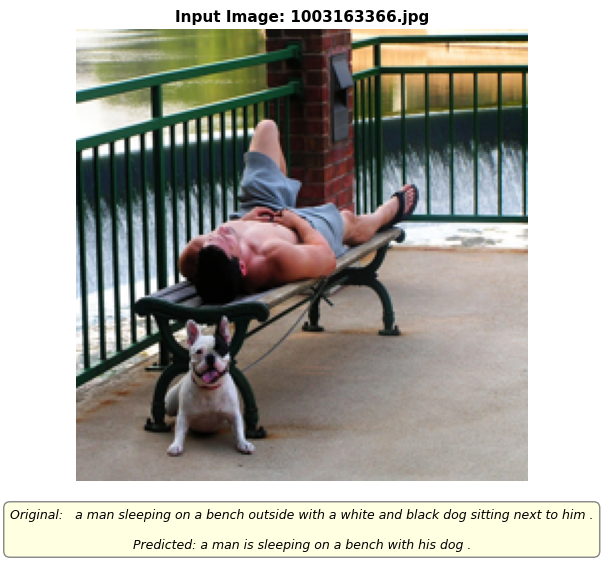

Saved: 1003163366_fig1_captions.png

Running LIME (1500 samples)...


  0%|          | 0/1500 [00:00<?, ?it/s]


Top-5 regions:
  R1  seg= 16  weight=-0.0153  [hurts caption]
  R2  seg= 10  weight=-0.0106  [hurts caption]
  R3  seg= 24  weight=-0.0102  [hurts caption]
  R4  seg= 32  weight=+0.0085  [helps caption]
  R5  seg= 17  weight=-0.0077  [hurts caption]


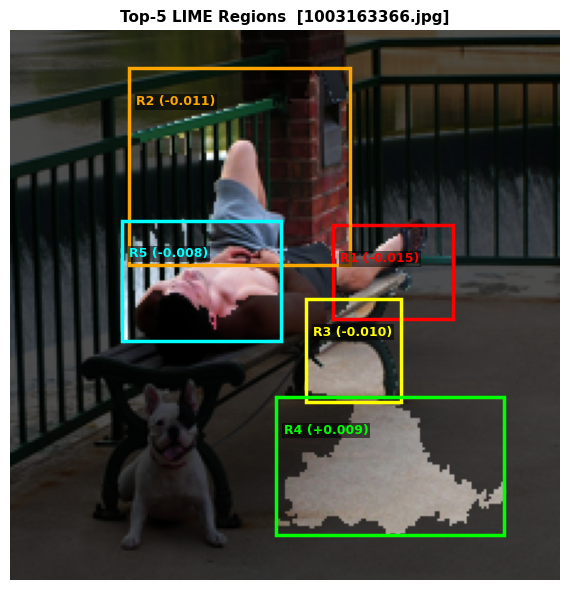

Saved: 1003163366_fig2_regions.png

Computing cross-attention scores...


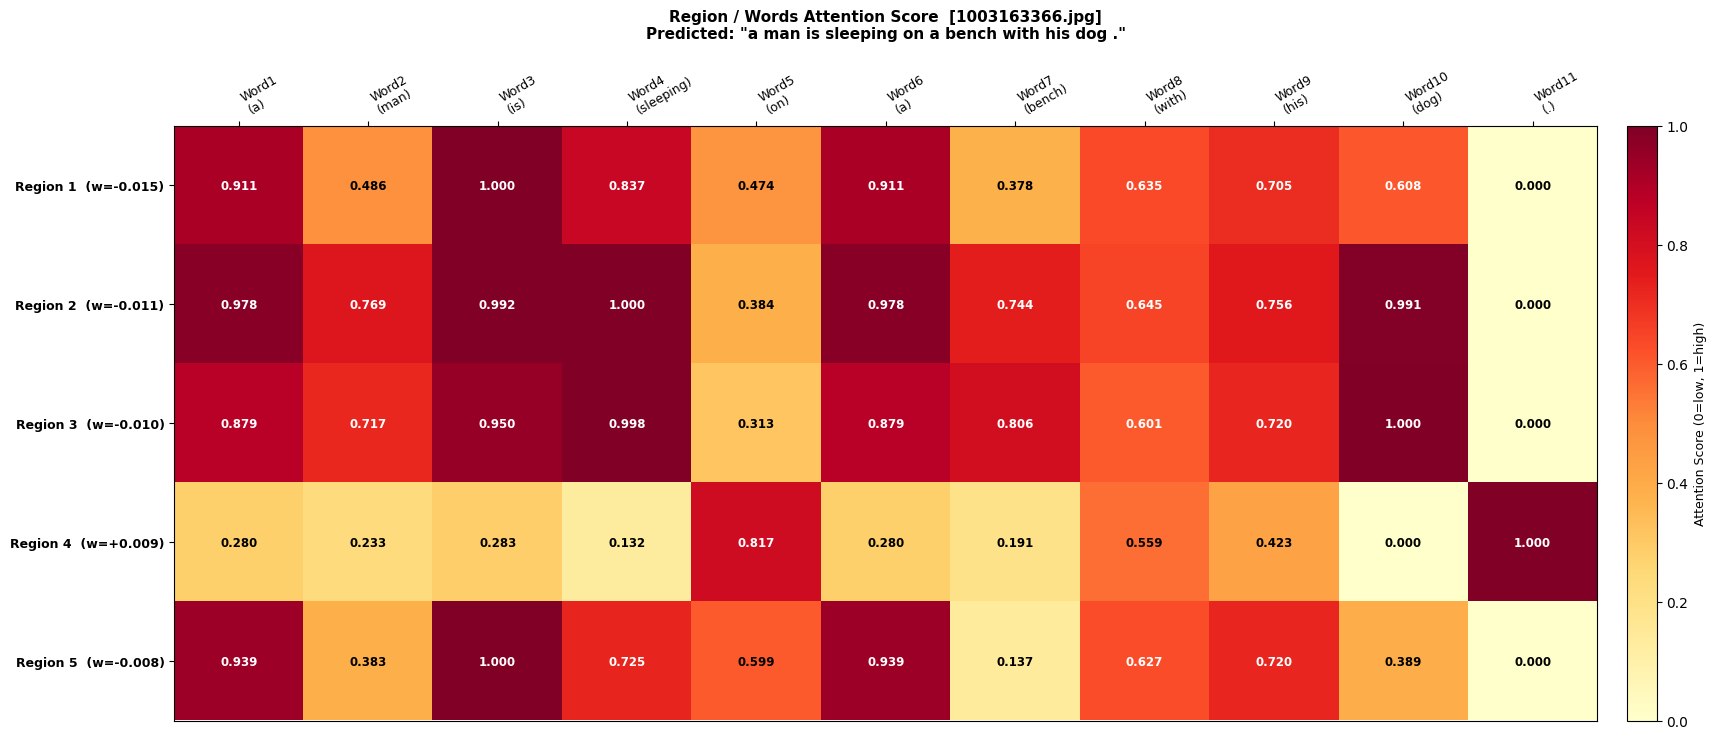

Saved: 1003163366_fig3_heatmap.png

----------------------------------------------------------------------------------------------------------------------------------------------------
Region/Words           Word1       Word2       Word3       Word4       Word5       Word6       Word7       Word8       Word9      Word10      Word11
                         (a)       (man)        (is)  (sleeping)        (on)         (a)     (bench)      (with)       (his)       (dog)         (.)
----------------------------------------------------------------------------------------------------------------------------------------------------
Region 1              0.9109      0.4858      1.0000      0.8374      0.4740      0.9109      0.3781      0.6348      0.7053      0.6081      0.0000
Region 2              0.9780      0.7692      0.9923      1.0000      0.3842      0.9780      0.7442      0.6452      0.7560      0.9910      0.0000
Region 3              0.8794      0.7169      0.9505      0.9979      

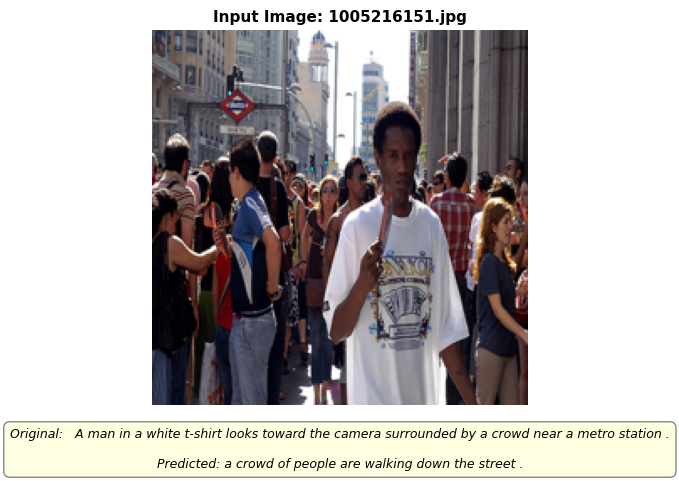

Saved: 1005216151_fig1_captions.png

Running LIME (1500 samples)...


  0%|          | 0/1500 [00:00<?, ?it/s]


Top-5 regions:
  R1  seg=  3  weight=-0.0164  [hurts caption]
  R2  seg=  6  weight=-0.0150  [hurts caption]
  R3  seg= 26  weight=+0.0086  [helps caption]
  R4  seg= 24  weight=+0.0085  [helps caption]
  R5  seg= 31  weight=+0.0074  [helps caption]


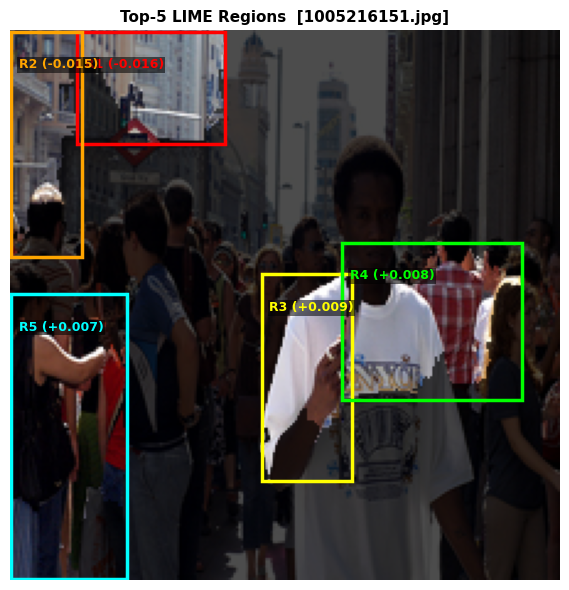

Saved: 1005216151_fig2_regions.png

Computing cross-attention scores...


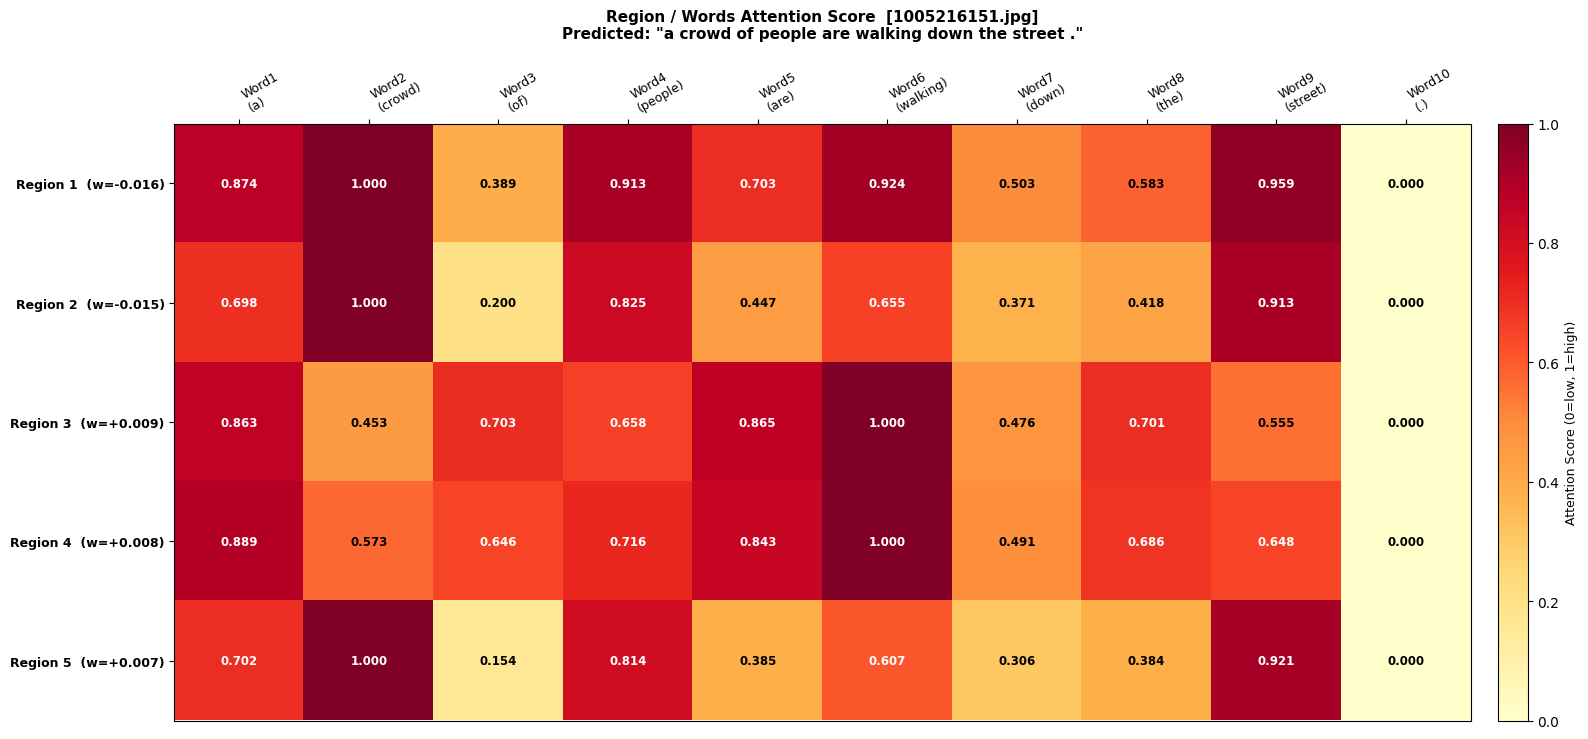

Saved: 1005216151_fig3_heatmap.png

------------------------------------------------------------------------------------------------------------------------------
Region/Words          Word1      Word2      Word3      Word4      Word5      Word6      Word7      Word8      Word9     Word10
                        (a)    (crowd)       (of)   (people)      (are)  (walking)     (down)      (the)   (street)        (.)
------------------------------------------------------------------------------------------------------------------------------
Region 1             0.8737     1.0000     0.3894     0.9128     0.7027     0.9242     0.5031     0.5831     0.9587     0.0000
Region 2             0.6980     1.0000     0.2005     0.8247     0.4472     0.6548     0.3714     0.4184     0.9132     0.0000
Region 3             0.8628     0.4529     0.7033     0.6580     0.8646     1.0000     0.4764     0.7011     0.5550     0.0000
Region 4             0.8889     0.5728     0.6455     0.7158     0.8433    

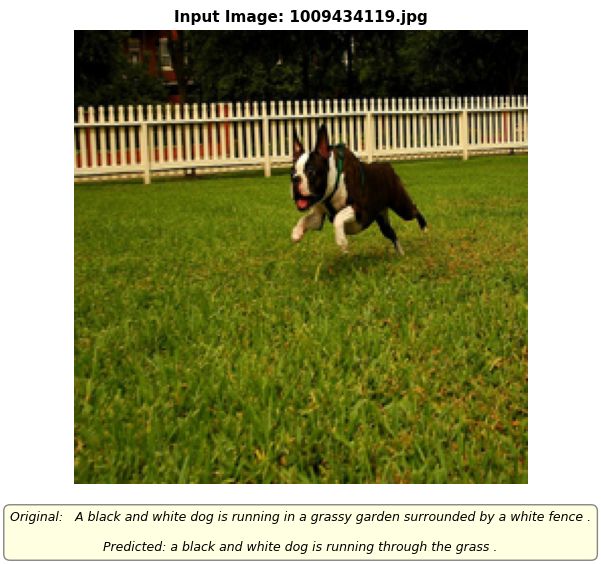

Saved: 1009434119_fig1_captions.png

Running LIME (1500 samples)...


  0%|          | 0/1500 [00:00<?, ?it/s]


Top-5 regions:
  R1  seg= 10  weight=-0.0264  [hurts caption]
  R2  seg=  9  weight=-0.0253  [hurts caption]
  R3  seg=  7  weight=-0.0201  [hurts caption]
  R4  seg= 12  weight=-0.0149  [hurts caption]
  R5  seg= 14  weight=-0.0099  [hurts caption]


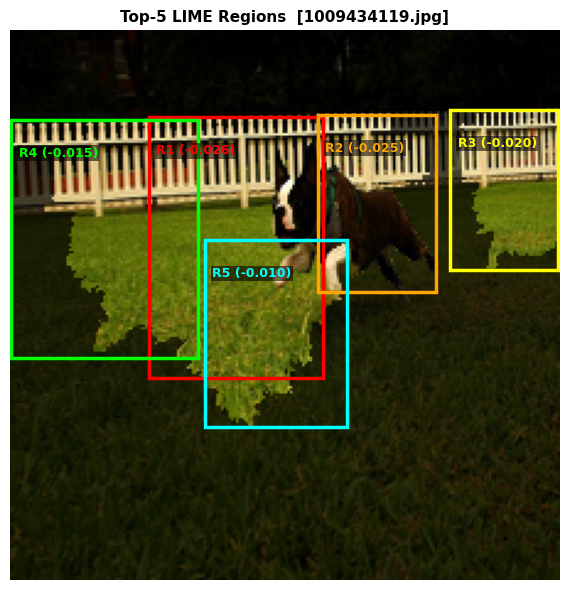

Saved: 1009434119_fig2_regions.png

Computing cross-attention scores...


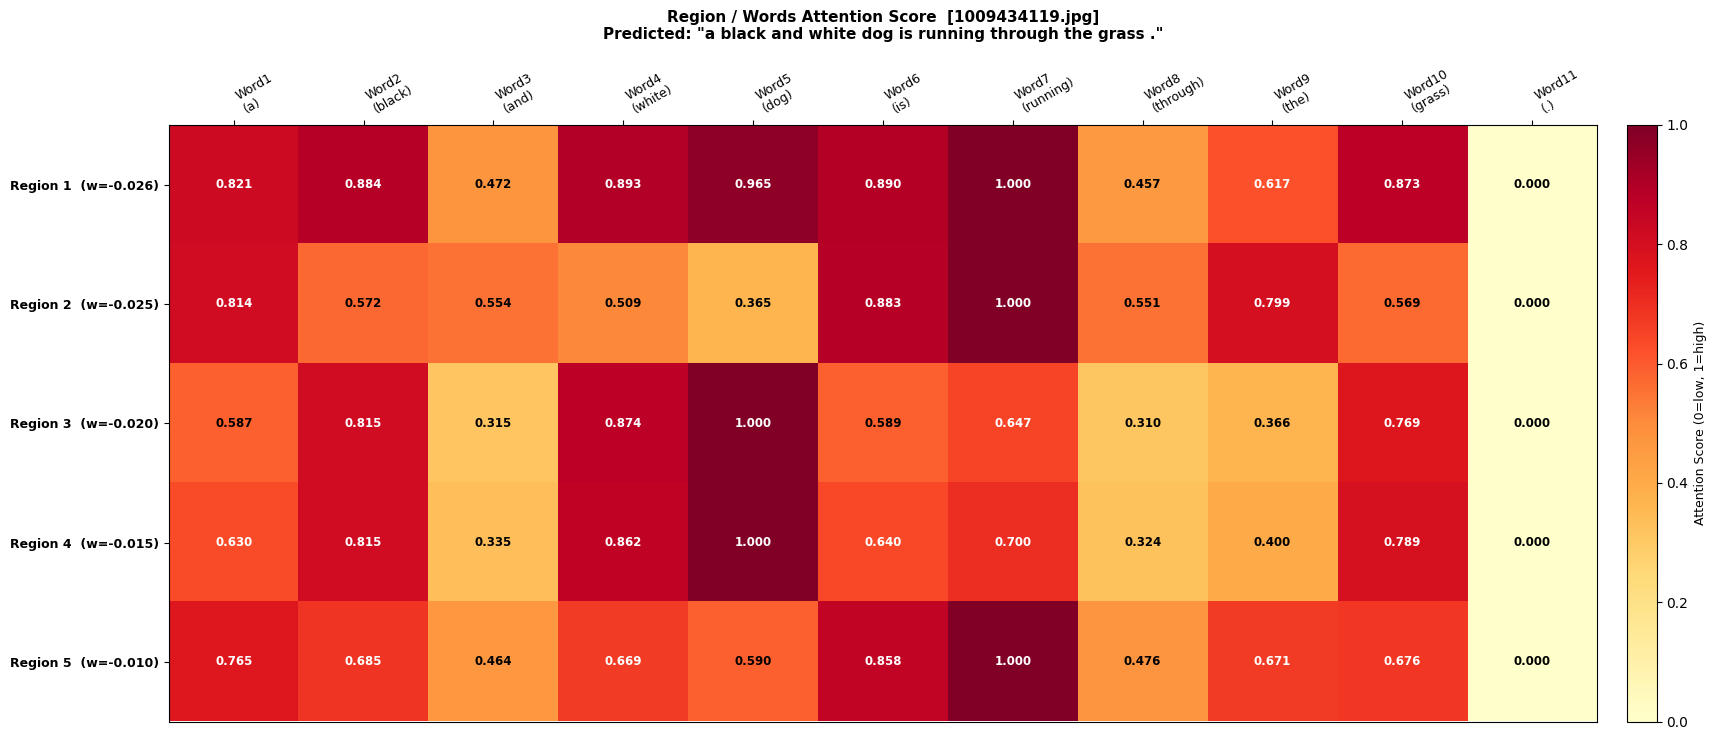

Saved: 1009434119_fig3_heatmap.png

-----------------------------------------------------------------------------------------------------------------------------------------
Region/Words          Word1      Word2      Word3      Word4      Word5      Word6      Word7      Word8      Word9     Word10     Word11
                        (a)    (black)      (and)    (white)      (dog)       (is)  (running)  (through)      (the)    (grass)        (.)
-----------------------------------------------------------------------------------------------------------------------------------------
Region 1             0.8211     0.8840     0.4718     0.8927     0.9651     0.8900     1.0000     0.4567     0.6174     0.8733     0.0000
Region 2             0.8137     0.5717     0.5536     0.5089     0.3647     0.8829     1.0000     0.5513     0.7990     0.5692     0.0000
Region 3             0.5868     0.8151     0.3150     0.8740     1.0000     0.5893     0.6465     0.3100     0.3660     0.7691     0.000

In [37]:
# ==============================================================
# LIME EXPLAINABILITY  -  3 Test Images Batch Run
# ==============================================================
# Runs explain_with_lime() on all 3 test images one by one.
# Each image produces 3 saved figures + console table.
# All outputs saved with image-name prefix so files don't overwrite.
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn.functional as F
import os
import warnings
warnings.filterwarnings('ignore')

from lime import lime_image


# ---------------------------------------------------------------
# PART 1 : CROSS-ATTENTION SCORE MATRIX
# ---------------------------------------------------------------
def get_attention_matrix(image_tensor, caption_words):
    model.eval()
    vocab = full_dataset.vocab

    if len(caption_words) == 0:
        return np.zeros((196, 1))

    with torch.no_grad():
        img_input      = image_tensor.unsqueeze(0).to(device)
        image_features = model.encoder(img_input)          # (1, 197, 512)

        token_ids = [
            vocab.stoi.get(w, vocab.stoi['<UNK>'])
            for w in caption_words
        ]
        token_tensor = torch.tensor(
            [token_ids], dtype=torch.long
        ).to(device)

        word_embeds = model.decoder.gpt.transformer.wte(token_tensor)

        _, attn_weights = model.decoder.cross_attention(
            query=word_embeds,
            key=image_features,
            value=image_features,
            need_weights=True,
            average_attn_weights=False
        )
        # attn_weights: (1, num_heads, num_words, 197)

    aw = attn_weights.squeeze(0).mean(dim=0).cpu().numpy()  # (num_words, 197)
    aw = aw[:, 1:]                                          # drop CLS -> (num_words, 196)
    return aw.T                                             # (196, num_words)


# ---------------------------------------------------------------
# PART 2 : LIME PREDICT FUNCTION  (caption log-prob score)
# ---------------------------------------------------------------
_lime_caption_token_ids = None

def lime_predict_fn(perturbed_images_np):
    global _lime_caption_token_ids
    model.eval()
    vocab  = full_dataset.vocab
    scores = []

    for img_np in perturbed_images_np:
        img_pil = Image.fromarray(
            (img_np * 255).astype(np.uint8)
        ).convert('RGB')
        img_t = val_transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            image_features = model.encoder(img_t)          # (1, 197, 512)

            if not _lime_caption_token_ids:
                score = float(image_features[:, 1:, :].mean().item())
                scores.append([1.0 - score, score])
                continue

            full_ids = (
                [vocab.stoi['<SOS>']]
                + _lime_caption_token_ids                  # includes <EOS>
            )
            cap_tensor    = torch.tensor(
                [full_ids], dtype=torch.long
            ).to(device)
            decoder_input = cap_tensor[:, :-1]
            target_ids    = cap_tensor[:, 1:]
            attn_mask     = (decoder_input != vocab.stoi['<PAD>']).long()

            logits, _     = model.decoder(
                image_features, decoder_input, attn_mask
            )                                              # (1, S, vocab_size)

            log_probs       = torch.nn.functional.log_softmax(logits, dim=-1)
            token_log_probs = log_probs.gather(
                2, target_ids.unsqueeze(-1)
            ).squeeze(-1)                                  # (1, S)

            pad_mask = (target_ids != vocab.stoi['<PAD>']).float()
            mean_lp  = (
                (token_log_probs * pad_mask).sum()
                / pad_mask.sum().clamp(min=1)
            ).item()

            score = float(
                torch.sigmoid(torch.tensor(mean_lp / 3.0)).item()
            )

        scores.append([1.0 - score, score])

    return np.array(scores, dtype=np.float32)


# ---------------------------------------------------------------
# PART 3 : MAP LIME SEGMENT -> ViT PATCH INDICES
# ---------------------------------------------------------------
PATCH_SIZE = 16
GRID_SIZE  = 14

def segment_to_patch_indices(segment_mask, overlap_threshold=0.20):
    h, w = segment_mask.shape[:2]
    if h != 224 or w != 224:
        m = Image.fromarray(
            segment_mask.astype(np.uint8) * 255
        ).resize((224, 224), Image.NEAREST)
        segment_mask = np.array(m) > 127

    patch_indices = []
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            y0 = row * PATCH_SIZE;  y1 = y0 + PATCH_SIZE
            x0 = col * PATCH_SIZE;  x1 = x0 + PATCH_SIZE
            overlap = segment_mask[y0:y1, x0:x1].sum() / (PATCH_SIZE * PATCH_SIZE)
            if overlap >= overlap_threshold:
                patch_indices.append(row * GRID_SIZE + col)

    if not patch_indices:
        patch_indices = [
            6 * GRID_SIZE + 6, 6 * GRID_SIZE + 7,
            7 * GRID_SIZE + 6, 7 * GRID_SIZE + 7,
        ]
    return patch_indices


# ---------------------------------------------------------------
# PART 4 : SINGLE IMAGE EXPLANATION
# ---------------------------------------------------------------
def explain_with_lime(image_path, top_regions=5,
                      num_lime_samples=800, save_prefix=None):
    """
    Run full LIME explanation for one image.

    Args:
        image_path       : full path to image
        top_regions      : how many top LIME regions to show (default 5)
        num_lime_samples : LIME perturbation count (default 800)
        save_prefix      : filename prefix for saved PNGs.
                           If None, uses the image stem (e.g. "1000092795")
    """
    global _lime_caption_token_ids
    vocab = full_dataset.vocab

    if save_prefix is None:
        save_prefix = os.path.splitext(os.path.basename(image_path))[0]

    # ── Load image ───────────────────────────────────────────────
    img_pil    = Image.open(image_path).convert('RGB')
    img_np     = np.array(img_pil.resize((224, 224)))
    img_tensor = val_transform(img_pil).to(device)

    # ── Predicted caption ────────────────────────────────────────
    predicted_caption = model.generate_caption(img_tensor, vocab)
    caption_words     = predicted_caption.split()
    num_words         = len(caption_words)

    # ── Cache caption tokens (with EOS) for lime_predict_fn ──────
    _lime_caption_token_ids = [
        vocab.stoi.get(w, vocab.stoi['<UNK>'])
        for w in caption_words
    ] + [vocab.stoi['<EOS>']]

    # ── Ground truth caption ─────────────────────────────────────
    img_filename = os.path.basename(image_path)
    try:
        original_caption = full_dataset.df[
            full_dataset.df['image_name'] == img_filename
        ]['comment'].iloc[0]
    except Exception:
        original_caption = "Not found in dataset"

    print("\n" + "=" * 70)
    print(f"  IMAGE: {img_filename}")
    print("=" * 70)
    print(f"  Original : {original_caption}")
    print(f"  Predicted: {predicted_caption}")
    print("=" * 70)

    # ── Figure 1 : Image + Captions ──────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(6, 6))
    ax1.imshow(img_np);  ax1.axis('off')
    ax1.set_title(f"Input Image: {img_filename}", fontsize=11, fontweight='bold')
    ax1.text(
        0.5, -0.06,
        f"Original:   {original_caption}\n\nPredicted: {predicted_caption}",
        transform=ax1.transAxes, ha='center', va='top',
        fontsize=9, style='italic',
        bbox=dict(facecolor='lightyellow', alpha=0.95,
                  edgecolor='gray', boxstyle='round,pad=0.5')
    )
    plt.tight_layout()
    f1_path = f"{save_prefix}_fig1_captions.png"
    plt.savefig(f1_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"Saved: {f1_path}")

    # ── Run LIME ──────────────────────────────────────────────────
    print(f"\nRunning LIME ({num_lime_samples} samples)...")
    explainer   = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np, lime_predict_fn,
        top_labels=1, num_samples=num_lime_samples, random_seed=42
    )
    label    = explanation.top_labels[0]
    segments = explanation.segments
    weights  = dict(explanation.local_exp[label])

    sorted_segs     = sorted(weights.items(),
                             key=lambda x: abs(x[1]), reverse=True)
    top_segment_ids = [sid for sid, _ in sorted_segs[:top_regions]]
    top_seg_weights = {sid: weights[sid] for sid in top_segment_ids}

    print(f"\nTop-{top_regions} regions:")
    for rank, sid in enumerate(top_segment_ids):
        w    = top_seg_weights[sid]
        sign = "helps" if w > 0 else "hurts"
        print(f"  R{rank+1}  seg={sid:3d}  weight={w:+.4f}  [{sign} caption]")

    # ── Figure 2 : LIME regions on image ─────────────────────────
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    display        = img_np.astype(float) / 255.0
    highlight_mask = np.zeros((224, 224), dtype=bool)
    for sid in top_segment_ids:
        highlight_mask |= (segments == sid)
    display[~highlight_mask] *= 0.30

    ax2.imshow(display);  ax2.axis('off')
    ax2.set_title(f"Top-{top_regions} LIME Regions  [{img_filename}]",
                  fontsize=11, fontweight='bold')

    region_colors = ['red', 'orange', 'yellow', 'lime', 'cyan']
    for rank, sid in enumerate(top_segment_ids):
        mask   = (segments == sid)
        coords = np.argwhere(mask)
        if len(coords) == 0:
            continue
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        color  = region_colors[rank % len(region_colors)]
        w_val  = top_seg_weights[sid]
        ax2.add_patch(patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2.5, edgecolor=color, facecolor='none'
        ))
        ax2.text(
            x_min + 3, y_min + 15,
            f"R{rank+1} ({'+' if w_val > 0 else ''}{w_val:.3f})",
            color=color, fontsize=9, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.55, pad=1, edgecolor='none')
        )

    plt.tight_layout()
    f2_path = f"{save_prefix}_fig2_regions.png"
    plt.savefig(f2_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"Saved: {f2_path}")

    # ── Attention matrix ─────────────────────────────────────────
    print("\nComputing cross-attention scores...")
    attention_matrix  = get_attention_matrix(img_tensor, caption_words)

    region_word_table = np.zeros((top_regions, num_words))
    for row_i, sid in enumerate(top_segment_ids):
        seg_mask   = (segments == sid)
        patch_idxs = segment_to_patch_indices(seg_mask)
        valid_idxs = [p for p in patch_idxs if p < attention_matrix.shape[0]]
        if valid_idxs:
            region_attn = attention_matrix[valid_idxs, :].mean(axis=0)
            region_word_table[row_i, :] = region_attn[:num_words]

    for r in range(top_regions):
        mn, mx = region_word_table[r].min(), region_word_table[r].max()
        if mx > mn:
            region_word_table[r] = (region_word_table[r] - mn) / (mx - mn)

    # ── Figure 3 : Heatmap ───────────────────────────────────────
    fig3_w = max(10, num_words * 1.3 + 3)
    fig3_h = top_regions * 1.0 + 2.5
    fig3, ax3 = plt.subplots(figsize=(fig3_w, fig3_h))

    im = ax3.imshow(region_word_table, cmap='YlOrRd',
                    aspect='auto', vmin=0, vmax=1)

    ax3.set_xticks(range(num_words))
    ax3.set_xticklabels(
        [f"Word{i+1}\n({w})" for i, w in enumerate(caption_words)],
        rotation=30, ha='left', fontsize=9
    )
    ax3.xaxis.set_label_position('top');  ax3.xaxis.tick_top()

    ax3.set_yticks(range(top_regions))
    ax3.set_yticklabels(
        [f"Region {i+1}  (w={top_seg_weights[top_segment_ids[i]]:+.3f})"
         for i in range(top_regions)],
        fontsize=9, fontweight='bold'
    )

    for r in range(top_regions):
        for c in range(num_words):
            val = region_word_table[r, c]
            ax3.text(c, r, f"{val:.3f}",
                     ha='center', va='center', fontsize=8.5,
                     color='white' if val > 0.6 else 'black',
                     fontweight='bold')

    ax3.set_title(
        f"Region / Words Attention Score  [{img_filename}]\n"
        f"Predicted: \"{predicted_caption}\"",
        fontsize=11, fontweight='bold', pad=16
    )
    plt.colorbar(im, ax=ax3, fraction=0.025, pad=0.02).set_label(
        'Attention Score (0=low, 1=high)', fontsize=9
    )
    plt.tight_layout()
    f3_path = f"{save_prefix}_fig3_heatmap.png"
    plt.savefig(f3_path, dpi=150, bbox_inches='tight');  plt.show()
    print(f"Saved: {f3_path}")

    # ── Console table ─────────────────────────────────────────────
    col_w   = max(10, max(len(w) for w in caption_words) + 4)
    divider = "-" * (16 + col_w * num_words)
    print(f"\n{divider}")
    print(f"{'Region/Words':<16}" + "".join(
        f"{('Word'+str(i+1)):>{col_w}}" for i in range(num_words)))
    print(f"{'':16}" + "".join(
        f"{('('+w+')'):>{col_w}}" for w in caption_words))
    print(divider)
    for r in range(top_regions):
        print(f"{'Region '+str(r+1):<16}" + "".join(
            f"{region_word_table[r, c]:>{col_w}.4f}"
            for c in range(num_words)))
    print(divider)

    return {
        'image'            : img_filename,
        'original_caption' : original_caption,
        'predicted_caption': predicted_caption,
        'top_segment_ids'  : top_segment_ids,
        'top_seg_weights'  : top_seg_weights,
        'region_word_table': region_word_table,
        'caption_words'    : caption_words,
    }


# ================================================================
# BATCH RUN : 3 TEST IMAGES
# ================================================================
test_image_paths = [
    data_location + "/flickr30k_images/1003163366.jpg",
    data_location + "/flickr30k_images/1005216151.jpg",
    data_location + "/flickr30k_images/1009434119.jpg",
]

all_results = {}

for img_path in test_image_paths:
    img_name = os.path.basename(img_path)

    if not os.path.exists(img_path):
        print(f"\n[SKIP] File not found: {img_path}")
        continue

    result = explain_with_lime(
        image_path       = img_path,
        top_regions      = 5,
        num_lime_samples = 1500,       # increase to 1500 for sharper regions
        save_prefix      = os.path.splitext(img_name)[0],
    )
    all_results[img_name] = result


# ================================================================
# SUMMARY TABLE : all 3 images side by side
# ================================================================
print("\n\n" + "=" * 70)
print("  BATCH SUMMARY")
print("=" * 70)
print(f"{'Image':<20} {'Predicted Caption':<45} {'Top Region Weight':>18}")
print("-" * 70)
for img_name, res in all_results.items():
    top_w = max(abs(w) for w in res['top_seg_weights'].values())
    cap   = res['predicted_caption'][:43] + ".." \
            if len(res['predicted_caption']) > 45 else res['predicted_caption']
    print(f"{img_name:<20} {cap:<45} {top_w:>18.4f}")
print("=" * 70)
print(f"\nTotal images processed: {len(all_results)} / {len(test_image_paths)}")
print("\nSaved files per image (prefix = image stem):")
print("  <stem>_fig1_captions.png  -> image + original + predicted captions")
print("  <stem>_fig2_regions.png   -> top-5 LIME region boxes")
print("  <stem>_fig3_heatmap.png   -> region x word attention heatmap")